In [ ]:
import numpy as np
from scipy import stats
from scipy.stats import norm, t, chi2, f, binom, poisson, expon, uniform, bernoulli, geom
import matplotlib.pyplot as plt


# Poisson-fordeling: X ~ Pois(λ)
# Antal hændelser i fast tidsinterval/område
# LaTeX: P(X=k) = \frac{\lambda^k}{k!}e^{-\lambda}, \quad k = 0,1,2,\ldots
# LaTeX: E[X] = \lambda, \quad Var(X) = \lambda

# VIGTIGT: λ skal matche det interval du ønsker sandsynligheden for!
# Eksempel: Hvis λ = 4 per minut, og du vil finde P(X ≥ 2) på 30 sekunder:
#   λ_30sek = 4 * (30/60) = 4 * 0.5 = 2
#   X_30sek = stats.poisson(2)
#   P(X ≥ 2) = 1 - P(X ≤ 1) = 1 - X_30sek.cdf(1)

lambda_rate = 4  # λ - gennemsnitlig rate per [tidsinterval]
X = stats.poisson(lambda_rate)

# Middelværdi: E[X] = λ
# Varians: Var(X) = λ
print(f"E[X] = {X.mean():.4f}")
print(f"Var(X) = {X.var():.4f}")
print(f"P(X = {6}) = {X.pmf(6):.4f}")



E[X] = 4.0000
Var(X) = 4.0000
P(X = 6) = 0.1042


$ P(X=k) = \frac{\lambda^k}{k!}e^{-\lambda} $

### ===========================

In [ ]:
# Z-test for andel p (proportion test)
# BRUG NÅR: Test af andel/proportion
# Krav: n×p₀≥5 OG n×(1-p₀)≥5
# Bruger Z-FORDELING (standard normal)
# H₀: p = p₀  vs  H₁: p ≠ p₀ (tosidet)
# LaTeX: Z = \frac{\hat{p} - p_0}{\sqrt{\frac{p_0(1-p_0)}{n}}}
# LaTeX: p = 2\Phi(-|Z|) = 2(1 - \Phi(|Z|))

# Observeret data
successes = 72  # Antal succeser
n = 200  # Stikprøvestørrelse
p_hat = successes / n  # p̂ - Observeret andel

# Nulhypotese
p_0 = 0.3  # p₀ - Nulhypotesens værdi for andelen

# Standardfejl under H₀: SE = √(p₀(1-p₀)/n)
SE = np.sqrt(p_0 * (1 - p_0) / n)

# Teststatistik: Z = (p̂ - p₀) / SE
z_stat = (p_hat - p_0) / SE

# Kritisk værdi
alpha = 0.05  # Signifikansniveau
z_critical = stats.norm.ppf(1 - alpha/2)

# p-værdi (tosidet): p = 2(1 - Φ(|Z|))
p_value = 2 * (1 - stats.norm.cdf(abs(z_stat)))

print(f"Observeret: {successes}/{n} = {p_hat:.4f}")
print(f"H₀: p = {p_0}")
print(f"H₁: p ≠ {p_0}")
print(f"SE = √(p₀(1-p₀)/n) = {SE:.4f}")
print(f"Teststatistik Z = {z_stat:.4f}")
print(f"Kritisk værdi: ±{z_critical:.4f}")
print(f"p-værdi = {p_value:.4f}")
print(f"Konklusion: {'Forkast H₀' if abs(z_stat) > z_critical else 'Forkast ikke H₀'}")

Observeret: 72/200 = 0.3600
H₀: p = 0.3
H₁: p ≠ 0.3
SE = √(p₀(1-p₀)/n) = 0.0324
Teststatistik Z = 1.8516
Kritisk værdi: ±1.9600
p-værdi = 0.0641
Konklusion: Forkast ikke H₀


In [ ]:
# t-test for middelværdi μ (ukendt populationsvarians)
# BRUG NÅR: Populationsstandardafvigelse σ er UKENDT - bruger stikprøve s
# Bruger T-FORDELING med df = n-1 frihedsgrader
# Antager: Data er tilnærmelsesvis normalfordelt
# H₀: μ = μ₀  vs  H₁: μ ≠ μ₀ (tosidet)
# LaTeX: t = \frac{\bar{x} - \mu_0}{s / \sqrt{n}}
# LaTeX: p = 2P(T_{n-1} > |t|) = 2(1 - F_{t,n-1}(|t|))
sample_mean = 10.5  # x̄ - Observeret stikprøvemiddelværdi
mu_0 = 10  # μ₀ - Nulhypotese værdi
s = 2  # s - Stikprøvestandardafvigelse (beregnet fra data)
n = 30  # Stikprøvestørrelse

# Teststatistik: t = (x̄ - μ₀) / (s/√n)
t_stat = (sample_mean - mu_0) / (s / np.sqrt(n))
df = n - 1  # Frihedsgrader

alpha = 0.05  # Signifikansniveau
t_critical = stats.t.ppf(1 - alpha/2, df)
# p-værdi (tosidet): p = 2(1 - F_t(|t|))
p_value = 2 * (1 - stats.t.cdf(abs(t_stat), df))

print(f"H₀: μ = {mu_0}")
print(f"H₁: μ ≠ {mu_0}")
print(f"t({df}) = {t_stat:.4f}")
print(f"Kritisk værdi: ±{t_critical:.4f}")
print(f"p-værdi = {p_value:.4f}")
print(f"Konklusion: {'Forkast H₀' if abs(t_stat) > t_critical else 'Forkast ikke H₀'}")

In [11]:
# Konfidensinterval for middelværdi μ (ukendt populationsvarians)
# BRUG NÅR: Populationsstandardafvigelse σ er UKENDT - bruger stikprøve-std s
# Bruger T-FORDELING med df = n-1 frihedsgrader
# Antager: Data er tilnærmelsesvis normalfordelt
# CI: x̄ ± t_{α/2,n-1} × (s/√n)
# LaTeX: CI = \left[\bar{x} - t_{\alpha/2,n-1}\frac{s}{\sqrt{n}}, \bar{x} + t_{\alpha/2,n-1}\frac{s}{\sqrt{n}}\right]
alpha = 0.05  # Signifikansniveau
sample_mean = 175  # x̄ - Observeret stikprøvemiddelværdi
s = 8  # s - Stikprøvestandardafvigelse (beregnet fra data)
n = 50  # Stikprøvestørrelse

df = n - 1  # Frihedsgrader
t_critical = stats.t.ppf(1 - alpha/2, df)
SE = s / np.sqrt(n)
margin_error = t_critical * SE

lower_bound = sample_mean - margin_error
upper_bound = sample_mean + margin_error

print(f"{(1-alpha)*100:.0f}% Konfidensinterval: ({lower_bound:.4f}, {upper_bound:.4f})")
print(f"Frihedsgrader: {df}")

95% Konfidensinterval: (172.7264, 177.2736)
Frihedsgrader: 49


En sygdom forekommer hos 1 % af befolkningen. En test har sensitivitet 95 % (P(positiv | syg) = 0,95) og specificitet 90 % (P(negativ | rask) = 0,90). Hvad er sandsynligheden for, at en person faktisk er syg, givet en positiv test? Opstil Bayes' regel og beregn.

$$ P(B) = \sum_{i=1}^n P(B|A_i)P(A_i) $$

$$ P(A|B) = \frac{P(B|A) \cdot P(A)}{P(B)} $$

In [ ]:
P_syg = 1/100
P_p_syg = 95/100
P_np_nsyg = 90/100



# Total sandsynlighedsformel: P(B) = Σ P(B|Aᵢ) × P(Aᵢ)
# Total probability: når B kan ske gennem flere partitioner
# LaTeX: P(B) = \sum_{i=1}^n P(B|A_i)P(A_i)
events = ['positiv given syg', 'positiv given not syg']
P_B_given_A = [P_p_syg, 1-P_np_nsyg]  # P(B|Aᵢ) for hver partition
P_A = [P_syg, 1-P_syg]  # P(Aᵢ) - sandsynlighed for hver partition

P_p= sum(p_ba * p_a for p_ba, p_a in zip(P_B_given_A, P_A))
print(f"P(B) = {P_B:.4f}")


P_A_given_B = (P_p_syg * P_syg) / P_p
print(f"P(syg|p) = {P_A_given_B:.4f}")

P(B) = 0.1085
P(syg|p) = 0.0876


$$ e_i = y_i - \hat{y}_i = y_i - (\hat{\beta}_0 + \hat{\beta}_1 x_i) $$

residuals: [-0.1  1.2  1.5 -0.2  0.1]


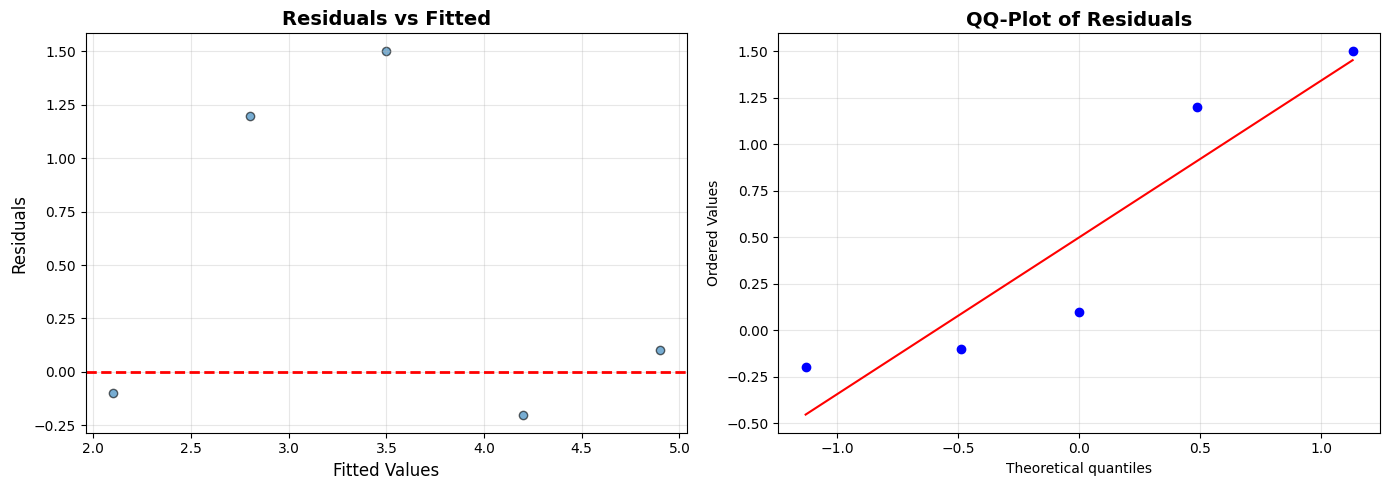

In [4]:
import numpy as np
from scipy import stats
from scipy.stats import norm, t, chi2, f, binom, poisson, expon, uniform, bernoulli, geom
import matplotlib.pyplot as plt

# Residualplot: tjek modelantagelser
# Residualer bruges til at validere regression antagelser
# LaTeX: e_i = y_i - \hat{y}_i = y_i - (\hat{\beta}_0 + \hat{\beta}_1 x_i)
# Antagelser: E[ε]=0, Var(ε)=σ² (konstant), ε~N(0,σ²), uafhængige
from scipy import stats as sp_stats


data = np.array([(1,2), (2,4), (3,5), (4,4), (5,5)]).T

x = data[0]
y = data[1]

# Beregn fitted values og residualer: e = y - ŷ
slope = 0.7
intercept = 1.4
fitted = slope * x + intercept  # ŷ
residuals = y - fitted  # e = y - ŷ

print(f"residuals: {residuals}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Residualer vs fitted values
ax1.scatter(fitted, residuals, alpha=0.6, edgecolors='black')
ax1.axhline(y=0, color='r', linestyle='--', linewidth=2)
ax1.set_xlabel('Fitted Values', fontsize=12)
ax1.set_ylabel('Residuals', fontsize=12)
ax1.set_title('Residuals vs Fitted', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)

# QQ-plot af residualer
sp_stats.probplot(residuals, dist="norm", plot=ax2)
ax2.set_title('QQ-Plot of Residuals', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

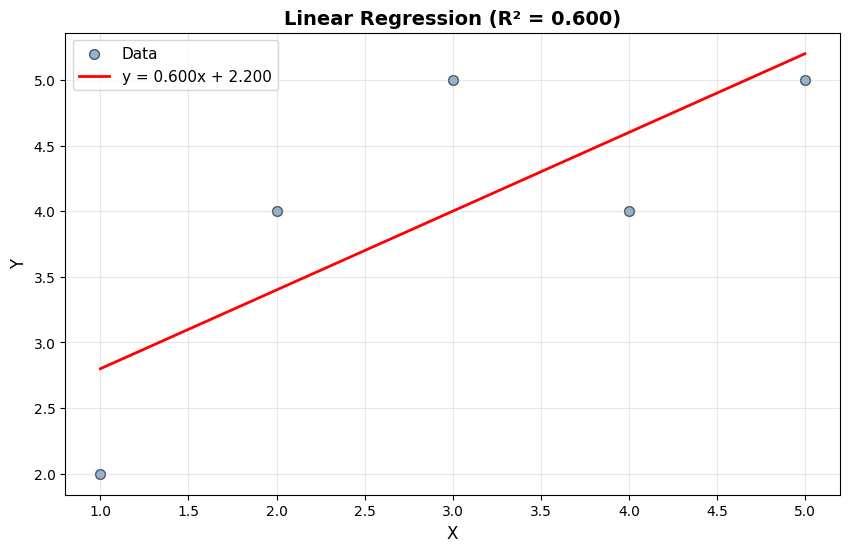

Model: y = 0.6000x + 2.2000
R² = 0.6000
p-value = 1.2403e-01


In [25]:
# Regressionsplot med fitted line
# Lineær regressionsmodel: Y = β₀ + β₁X + ε
# LaTeX: Y = \beta_0 + \beta_1 X + \varepsilon \text{ where } \varepsilon \sim N(0,\sigma^2)
# LaTeX: \hat{\beta}_1 = \frac{\sum(x_i-\bar{x})(y_i-\bar{y})}{\sum(x_i-\bar{x})^2}, \quad \hat{\beta}_0 = \bar{y} - \hat{\beta}_1\bar{x}
# LaTeX: R^2 = 1 - \frac{SS_{res}}{SS_{tot}} = \frac{\sum(\hat{y}_i-\bar{y})^2}{\sum(y_i-\bar{y})^2}
from scipy import stats as sp_stats

x = data[0]
y = data[1]

# Beregn lineær regression: y = β₀ + β₁x
slope, intercept, r_value, p_value, std_err = sp_stats.linregress(x, y)
line = slope * x + intercept  # ŷ = β̂₀ + β̂₁x

plt.figure(figsize=(10, 6))
plt.scatter(x, y, alpha=0.6, s=50, label='Data', color='steelblue', edgecolors='black')
plt.plot(x, line, 'r-', linewidth=2, label=f'y = {slope:.3f}x + {intercept:.3f}')
plt.xlabel('X', fontsize=12)
plt.ylabel('Y', fontsize=12)
plt.title(f'Linear Regression (R² = {r_value**2:.3f})', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.show()

print(f"Model: y = {slope:.4f}x + {intercept:.4f}")
print(f"R² = {r_value**2:.4f}")
print(f"p-value = {p_value:.4e}")

$$ R^2 = 1 - \frac{SSE}{SST} $$

═══════════════════════════════════════════════════════════════════════════
FORMLER
═══════════════════════════════════════════════════════════════════════════




**Regressionsmodel:**
$$ Y = \beta_0 + \beta_1 X + \varepsilon \quad \text{hvor} \quad \varepsilon \sim N(0,\sigma^2) $$

**Hældning (slope):**
$$ \hat{\beta}_1 = \frac{S_{XY}}{S_{XX}} = \frac{\sum(x_i-\bar{x})(y_i-\bar{y})}{\sum(x_i-\bar{x})^2} $$

**Skæring (intercept):**
$$ \hat{\beta}_0 = \bar{y} - \hat{\beta}_1\bar{x} $$

**Sum of Squares:**
$$ S_{XX} = \sum(x_i-\bar{x})^2, \quad S_{YY} = \sum(y_i-\bar{y})^2, \quad S_{XY} = \sum(x_i-\bar{x})(y_i-\bar{y}) $$

$$ SSE = \sum(y_i - \hat{y}_i)^2, \quad SST = \sum(y_i - \bar{y})^2, \quad SSR = SST - SSE $$

**Forklaringsgrad (R²):**
$$ R^2 = \frac{S_{XY}^2}{S_{XX} \cdot S_{YY}} = 1 - \frac{SSE}{SST} $$

**Signifikanstest (H₀: β₁ = 0):**
$$ s_r^2 = \frac{SSE}{n-2}, \quad SE(\hat{\beta}_1) = \sqrt{\frac{s_r^2}{S_{XX}}} $$

$$ t = \frac{\hat{\beta}_1}{SE(\hat{\beta}_1)}, \quad df = n-2 $$

$$ p = 2P(T_{n-2} > |t|) = 2(1 - F_{t,n-2}(|t|)) $$



═══════════════════════════════════════════════════════════════════════════
DATA
═══════════════════════════════════════════════════════════════════════════
n = 5
x = [1 2 3 4 5]
y = [2 4 5 4 5]

═══════════════════════════════════════════════════════════════════════════
REGRESSIONSMODEL
═══════════════════════════════════════════════════════════════════════════
ŷ = 1.4000 + 0.7000x
β̂₀ (intercept) = 1.4000
β̂₁ (slope) = 0.7000

═══════════════════════════════════════════════════════════════════════════
FITTED VALUES & RESIDUALS
═══════════════════════════════════════════════════════════════════════════
x̄ = 3.0000
ȳ = 4.0000

x[0]=1.00  y[0]=2.00  ŷ[0]=2.1000  e[0]=-0.1000
x[1]=2.00  y[1]=4.00  ŷ[1]=2.8000  e[1]=1.2000
x[2]=3.00  y[2]=5.00  ŷ[2]=3.5000  e[2]=1.5000
x[3]=4.00  y[3]=4.00  ŷ[3]=4.2000  e[3]=-0.2000
x[4]=5.00  y[4]=5.00  ŷ[4]=4.9000  e[4]=0.1000

═══════════════════════════════════════════════════════════════════════════
SUM OF SQUARES
═══════════════════════════════════

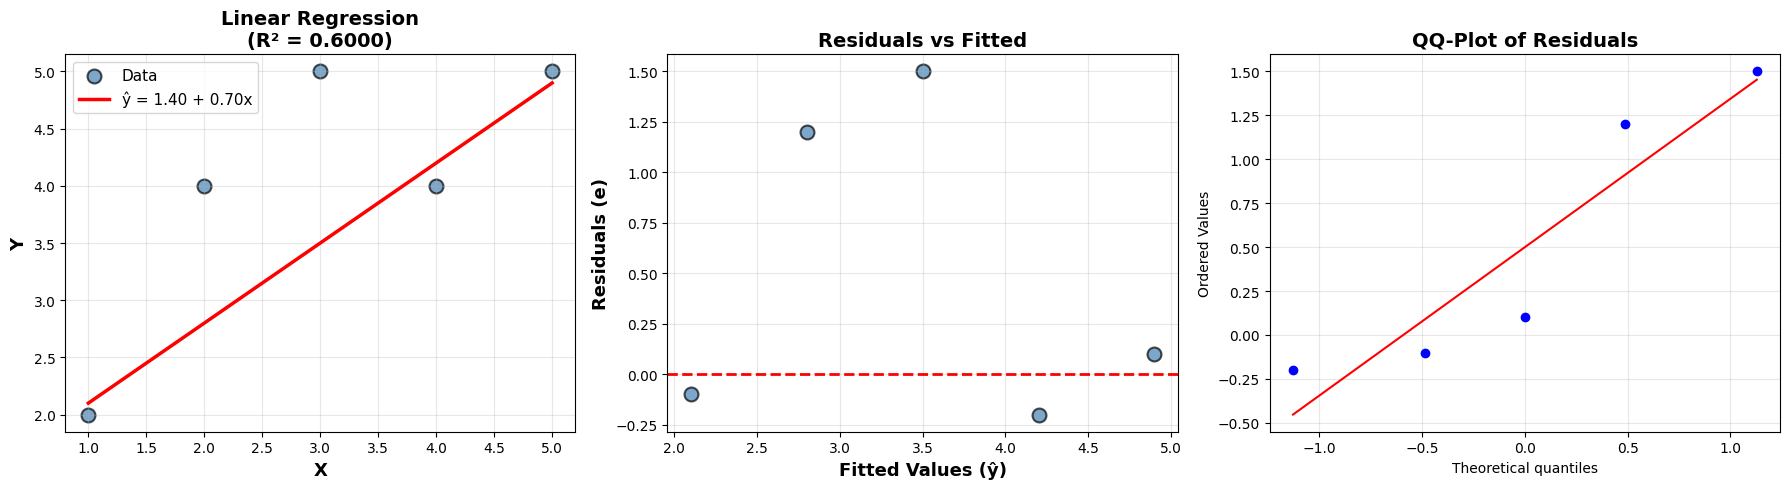

═══════════════════════════════════════════════════════════════════════════


In [6]:
# ═══════════════════════════════════════════════════════════════════════════
# LINEÆR REGRESSION - KOMPLET ANALYSE
# ═══════════════════════════════════════════════════════════════════════════

print('═══════════════════════════════════════════════════════════════════════════')
print('FORMLER')
print('═══════════════════════════════════════════════════════════════════════════')
print()
from IPython.display import display, Markdown
display(Markdown(r'''
**Regressionsmodel:**
$$ Y = \beta_0 + \beta_1 X + \varepsilon \quad \text{hvor} \quad \varepsilon \sim N(0,\sigma^2) $$

**Hældning (slope):**
$$ \hat{\beta}_1 = \frac{S_{XY}}{S_{XX}} = \frac{\sum(x_i-\bar{x})(y_i-\bar{y})}{\sum(x_i-\bar{x})^2} $$

**Skæring (intercept):**
$$ \hat{\beta}_0 = \bar{y} - \hat{\beta}_1\bar{x} $$

**Sum of Squares:**
$$ S_{XX} = \sum(x_i-\bar{x})^2, \quad S_{YY} = \sum(y_i-\bar{y})^2, \quad S_{XY} = \sum(x_i-\bar{x})(y_i-\bar{y}) $$

$$ SSE = \sum(y_i - \hat{y}_i)^2, \quad SST = \sum(y_i - \bar{y})^2, \quad SSR = SST - SSE $$

**Forklaringsgrad (R²):**
$$ R^2 = \frac{S_{XY}^2}{S_{XX} \cdot S_{YY}} = 1 - \frac{SSE}{SST} $$

**Signifikanstest (H₀: β₁ = 0):**
$$ s_r^2 = \frac{SSE}{n-2}, \quad SE(\hat{\beta}_1) = \sqrt{\frac{s_r^2}{S_{XX}}} $$

$$ t = \frac{\hat{\beta}_1}{SE(\hat{\beta}_1)}, \quad df = n-2 $$

$$ p = 2P(T_{n-2} > |t|) = 2(1 - F_{t,n-2}(|t|)) $$
'''))
print()

# DATA INPUT
x = data[0]
y = data[1]
n = len(x)

print('═══════════════════════════════════════════════════════════════════════════')
print('DATA')
print('═══════════════════════════════════════════════════════════════════════════')
print(f'n = {n}')
print(f'x = {x}')
print(f'y = {y}')
print()

# ───────────────────────────────────────────────────────────────────────────
# BEREGNINGER
# ───────────────────────────────────────────────────────────────────────────

# Middelværdier
x_bar = np.mean(x)
y_bar = np.mean(y)

# Sum of Squares
S_XX = np.sum((x - x_bar) ** 2)  # SSX = Σ(xᵢ-x̄)²
S_YY = np.sum((y - y_bar) ** 2)  # SSY = Σ(yᵢ-ȳ)²
S_XY = np.sum((x - x_bar) * (y - y_bar))  # SSXY = Σ(xᵢ-x̄)(yᵢ-ȳ)

# Regressionskoefficienter
beta_1 = 0.7
beta_0 = 1.4

# Fitted values og residualer
y_hat = beta_0 + beta_1 * x  # ŷ = β̂₀ + β̂₁x
residuals = y - y_hat  # e = y - ŷ

# Sum of Squares - Error og Total
SS_E = np.sum(residuals ** 2)  # SSE = Σ(yᵢ - ŷᵢ)² (residual sum of squares)
SS_T = S_YY  # SST = Σ(yᵢ - ȳ)² (total sum of squares)
SS_R = SS_T - SS_E  # SSR = SST - SSE (regression sum of squares)

# R² (forklaringsgrad)
R_squared = (S_XY ** 2) / (S_XX * S_YY)  # Metode 1
R_squared_alt = 1 - (SS_E / SS_T)  # Metode 2

# P-værdi (test for β₁ = 0)
df = n - 2
s_r_squared = SS_E / df  # Residual varians
SE_beta_1 = np.sqrt(s_r_squared / S_XX)  # Standard error af β̂₁
t_stat = beta_1 / SE_beta_1  # t-statistik
p_value = 2 * (1 - stats.t.cdf(abs(t_stat), df))  # p-værdi (tosidet)

# ───────────────────────────────────────────────────────────────────────────
# PRINT RESULTATER
# ───────────────────────────────────────────────────────────────────────────

print('═══════════════════════════════════════════════════════════════════════════')
print('REGRESSIONSMODEL')
print('═══════════════════════════════════════════════════════════════════════════')
print(f'ŷ = {beta_0:.4f} + {beta_1:.4f}x')
print(f'β̂₀ (intercept) = {beta_0:.4f}')
print(f'β̂₁ (slope) = {beta_1:.4f}')
print()

print('═══════════════════════════════════════════════════════════════════════════')
print('FITTED VALUES & RESIDUALS')
print('═══════════════════════════════════════════════════════════════════════════')
print(f'x̄ = {x_bar:.4f}')
print(f'ȳ = {y_bar:.4f}')
print()
for i in range(n):
    print(f'x[{i}]={x[i]:.2f}  y[{i}]={y[i]:.2f}  ŷ[{i}]={y_hat[i]:.4f}  e[{i}]={residuals[i]:.4f}')
print()

print('═══════════════════════════════════════════════════════════════════════════')
print('SUM OF SQUARES')
print('═══════════════════════════════════════════════════════════════════════════')
print(f'S_XX  = Σ(xᵢ-x̄)² = {S_XX:.4f}')
print(f'S_YY  = Σ(yᵢ-ȳ)² = {S_YY:.4f}')
print(f'S_XY  = Σ(xᵢ-x̄)(yᵢ-ȳ) = {S_XY:.4f}')
print()
print(f'SSE   = Σ(yᵢ-ŷᵢ)² = {SS_E:.4f}  (Residual Sum of Squares)')
print(f'SST   = Σ(yᵢ-ȳ)² = {SS_T:.4f}  (Total Sum of Squares)')
print(f'SSR   = SST - SSE = {SS_R:.4f}  (Regression Sum of Squares)')
print()

print('═══════════════════════════════════════════════════════════════════════════')
print('MODELKVALITET')
print('═══════════════════════════════════════════════════════════════════════════')
print(f'R² = {R_squared:.4f}  ({R_squared*100:.2f}% af variationen forklares)')
print(f'Verificering: R² = 1 - SSE/SST = {R_squared_alt:.4f}')
print()

print('═══════════════════════════════════════════════════════════════════════════')
print('SIGNIFIKANSTEST (H₀: β₁ = 0)')
print('═══════════════════════════════════════════════════════════════════════════')
print(f's²ᵣ (residual varians) = {s_r_squared:.4f}')
print(f'SE(β̂₁) = {SE_beta_1:.4f}')
print(f't({df}) = {t_stat:.4f}')
print(f'p-værdi = {p_value:.6f}')
print()
alpha = 0.05
if p_value < alpha:
    print(f'✓ Signifikant lineær sammenhæng (p < {alpha})')
else:
    print(f'✗ Ingen signifikant lineær sammenhæng (p ≥ {alpha})')
print()

# ───────────────────────────────────────────────────────────────────────────
# PLOTS
# ───────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Scatter med regressionslinje
axes[0].scatter(x, y, alpha=0.7, s=100, label='Data', color='steelblue', edgecolors='black', linewidths=1.5)
axes[0].plot(x, y_hat, 'r-', linewidth=2.5, label=f'ŷ = {beta_0:.2f} + {beta_1:.2f}x')
axes[0].set_xlabel('X', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Y', fontsize=13, fontweight='bold')
axes[0].set_title(f'Linear Regression\n(R² = {R_squared:.4f})', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11, loc='best')
axes[0].grid(True, alpha=0.3)

# Plot 2: Residualer vs Fitted Values
axes[1].scatter(y_hat, residuals, alpha=0.7, s=100, color='steelblue', edgecolors='black', linewidths=1.5)
axes[1].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[1].set_xlabel('Fitted Values (ŷ)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Residuals (e)', fontsize=13, fontweight='bold')
axes[1].set_title('Residuals vs Fitted', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)

# Plot 3: QQ-plot af residualer
stats.probplot(residuals, dist='norm', plot=axes[2])
axes[2].set_title('QQ-Plot of Residuals', fontsize=14, fontweight='bold')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print('═══════════════════════════════════════════════════════════════════════════')

$$ E[X] = \sum x \cdot f_X(x), \quad Var(X) = E[X^2] - E[X]^2 $$

In [8]:
# Beregn middelværdi E[X] og varians Var(X) for diskret fordeling
# DANSK: E[X] = Σ x·f_X(x), Var(X) = E[X²] - E[X]²
# ENGLISH: E[X] = Σ x·f_X(x), Var(X) = E[X²] - E[X]²
# LaTeX: E[X] = \sum x \cdot f_X(x), \quad Var(X) = E[X^2] - E[X]^2

# Input: x-værdier og PMF-værdier
X = np.array([1,2,3])
f_X = np.array([0.2,0.5,0.3])  # PMF værdier (kan være ikke-normaliseret)

# Normaliser PMF (så summen = 1)
f_X_norm = f_X / f_X.sum()

# Beregn forventningsværdi: E[X] = Σ x·f_X(x)
E_X = np.sum(X * f_X_norm)

# Beregn E[X²] = Σ x²·f_X(x)
E_X2 = np.sum(X**2 * f_X_norm)

# Beregn varians: Var(X) = E[X²] - E[X]²
Var_X = E_X2 - E_X**2

# Beregn standardafvigelse: SD(X) = √Var(X)
SD_X = np.sqrt(Var_X)

# Print LaTeX formler
print("Udtryk for middelværdi:")
print("  E[X] = Σ x·f_X(x)")
print(r"  LaTeX: E[X] = \sum_{\text{alle } x} x \cdot f_X(x)")

print("\nUdtryk for varians:")
print("  Var(X) = E[X²] - E[X]²")
print("  Var(X) = Σ x²·f_X(x) - (Σ x·f_X(x))²")
print(r"  LaTeX: \text{Var}(X) = E[X^2] - E[X]^2 = \sum_{\text{alle } x} x^2 \cdot f_X(x) - \left(\sum_{\text{alle } x} x \cdot f_X(x)\right)^2")

# Print resultater
print("\nBeregninger:")
print(f"  E[X] = {E_X:.4f}")
print(f"  E[X²] = {E_X2:.4f}")
print(f"  Var(X) = {Var_X:.4f}")
print(f"  SD(X) = {SD_X:.4f}")

Udtryk for middelværdi:
  E[X] = Σ x·f_X(x)
  LaTeX: E[X] = \sum_{\text{alle } x} x \cdot f_X(x)

Udtryk for varians:
  Var(X) = E[X²] - E[X]²
  Var(X) = Σ x²·f_X(x) - (Σ x·f_X(x))²
  LaTeX: \text{Var}(X) = E[X^2] - E[X]^2 = \sum_{\text{alle } x} x^2 \cdot f_X(x) - \left(\sum_{\text{alle } x} x \cdot f_X(x)\right)^2

Beregninger:
  E[X] = 2.1000
  E[X²] = 4.9000
  Var(X) = 0.4900
  SD(X) = 0.7000


In [ ]:
# LOTUS - Law of the Unconscious Statistician (Diskret)
# E[g(X)] = Σ g(x) · p_X(x)
# Beregn forventningsværdi af en funktion g(X)

# Eksempel: X ~ Binomial(n=10, p=0.3), find E[X²]
n = 10
p = 0.3

# Definér funktion g(x)
def g(x):
    return x**2  # Eksempel: g(x) = x²

# Beregn E[g(X)] = Σ g(x) · P(X=x)
x_values = np.arange(0, n + 1)
pmf_values = stats.binom.pmf(x_values, n, p)  # p_X(x)
g_values = g(x_values)  # g(x)

E_gX = np.sum(g_values * pmf_values)

print(f'E[g(X)] = {E_gX:.4f}')
print()

# Verificering for g(x) = x²:
if 'x**2' == 'x**2':
    print('Verificering med g(x) = x²:')
    E_X = n * p
    Var_X = n * p * (1 - p)
    E_X2_formula = Var_X + E_X**2  # E[X²] = Var(X) + E[X]²
    print(f'E[X²] (LOTUS) = {E_gX:.4f}')
    print(f'E[X²] (formel) = Var(X) + E[X]² = {E_X2_formula:.4f}')

In [9]:

from math import comb
# Kombinationer uden tilbagelægning: C(n,k) = n!/(k!(n-k)!)
# Antal uordnede udvælgelser af k elementer fra n
# LaTeX: C(n,k) = \binom{n}{k} = \frac{n!}{k!(n-k)!}
n = 12
k = 4
result = comb(n, k)
print(f"C({n},{k}) = {result}")

C(12,4) = 495


In [11]:
# Beregn permutationer uden tilbagelægning P(n,k)
# DANSK: P(n,k) = n! / (n-k)!
# ENGLISH: P(n,k) = n! / (n-k)!
# LaTeX: P(n,k) = \frac{n!}{(n-k)!}

from math import perm, factorial

# Input
n = 12  # Total antal elementer
k = 3   # Antal elementer der vælges

# Beregn permutationer: P(n,k) = n! / (n-k)!
result = perm(n, k)

# Print LaTeX formel
print('Permutationer uden tilbagelægning:')
print('  P(n,k) = n! / (n-k)!')
print(r'  LaTeX: P(n,k) = \frac{n!}{(n-k)!}')
print()

# Print beregning
print('Beregning:')
print(f'  P({n},{k}) = {n}! / ({n}-{k})!')
print(f'  P({n},{k}) = {factorial(n)} / {factorial(n-k)}')
print(f'  P({n},{k}) = {result}')
print()
print(f'Antal ordnede udvælgelser af {k} elementer fra {n}: {result}')
print('(Rækkefølge BETYDER noget)')

Permutationer uden tilbagelægning:
  P(n,k) = n! / (n-k)!
  LaTeX: P(n,k) = \frac{n!}{(n-k)!}

Beregning:
  P(12,3) = 12! / (12-3)!
  P(12,3) = 479001600 / 362880
  P(12,3) = 1320

Antal ordnede udvælgelser af 3 elementer fra 12: 1320
(Rækkefølge BETYDER noget)


In [19]:
# Standardfejl (Standard Error): SE = σ/√n
# Spredning af stikprøvemiddelværdien
# LaTeX: SE = \frac{\sigma}{\sqrt{n}}
sigma = 20  # Populationsstandardafvigelse | Population std
n = 64  # Stikprøvestørrelse | Sample size
SE = sigma / np.sqrt(n)
print(f"SE = {SE:.4f}")

SE = 2.5000


$$ SE = \frac{\sigma}{\sqrt{n}} $$

In [23]:
# Central Limit Theorem: Sample Mean x̄ → Normal approximation
# LaTeX: \bar{X} = \frac{1}{n}\sum_{i=1}^{n} X_i \approx N\left(\mu, \frac{\sigma^2}{n}\right)
# LaTeX: \mu_{\bar{X}} = \mu, \quad \sigma_{\bar{X}}^2 = \frac{\sigma^2}{n}
# LaTeX: Z = \frac{\bar{X} - \mu}{\sigma/\sqrt{n}} \approx N(0,1)
# Gælder for enhver fordeling med veldefineret μ og σ når n ≥ 30

n = 64  # Stikprøvestørrelse
mu = 100  # Teoretisk middelværdi
sigma = 20  # Teoretisk standardafvigelse

# Sample mean → Normal parametre
mu_xbar = mu
sigma_xbar = sigma / np.sqrt(n)

print(f"x̄ ≈ N({mu_xbar:.2f}, {sigma_xbar**2:.4f})")
print(f"μ_x̄ = {mu_xbar:.2f}, σ_x̄ = {sigma_xbar:.4f}")

# Beregn sandsynlighed: P(x̄ > value)
value = 105  # Kritisk værdi

z = (value - mu_xbar) / sigma_xbar
p_greater = 1 - stats.norm.cdf(z)

print(f"")
print(f"P(x̄ > {value}):")
print(f"z = ({value}-{mu_xbar:.2f})/{sigma_xbar:.4f} = {z:.4f}")
print(f"P(x̄ > {value}) = P(Z > {z:.4f}) = {p_greater:.6f}")

# Beregn intervalsandsynlighed: P(a < x̄ < b)
a = 48
b = 52
z_a = (a - mu_xbar) / sigma_xbar
z_b = (b - mu_xbar) / sigma_xbar
p_interval = stats.norm.cdf(z_b) - stats.norm.cdf(z_a)
print(f"")
print(f"P({a} < x̄ < {b}) = {p_interval:.6f}")

x̄ ≈ N(100.00, 6.2500)
μ_x̄ = 100.00, σ_x̄ = 2.5000

P(x̄ > 105):
z = (105-100.00)/2.5000 = 2.0000
P(x̄ > 105) = P(Z > 2.0000) = 0.022750

P(48 < x̄ < 52) = 0.000000


**Type 1 vs Type 2 Fejl - Sammenligning**

---

## **1. DEFINITIONER**

| Fejltype | Symbol | Definition | Dansk beskrivelse |
|----------|--------|------------|-------------------|
| **Type 1** | α | P(Forkast H₀ \| H₀ sand) | Falsk positiv - konkluderer effekt når der ingen er |
| **Type 2** | β | P(Forkast ikke H₀ \| H₀ falsk) | Falsk negativ - overser effekt når den findes |

**Styrke (Power):**  - \beta$ = sandsynlighed for at detektere reel effekt

---

## **2. FORSKEL**

### **Type 1 fejl (α):**
- **Hvad:** Forkaster H₀ selvom den er sand
- **Konsekvens:** Falsk alarm - tror du fandt noget, men der er intet
- **Eksempel:** Konkluderer medicin virker → den gør IKKE
- **Analogi:** Brandalarmen går i gang → ingen brand

### **Type 2 fejl (β):**
- **Hvad:** Forkaster IKKE H₀ selvom den er falsk
- **Konsekvens:** Overser reel effekt - der ER noget, men du fandt det ikke
- **Eksempel:** Konkluderer medicin virker IKKE → den virker faktisk
- **Analogi:** Brandalarmen går IKKE i gang → men der ER brand

---

## **3. EFFEKT PÅ BESLUTNINGER**

### **Type 1 fejl:**
- Leder til unødvendige handlinger
- Spild af ressourcer på noget der ikke virker
- Kan skade troværdighed (falske fund)

### **Type 2 fejl:**
- Overser vigtige opdagelser
- Går glip af effektive behandlinger/løsninger
- Fortsætter med ineffektive metoder

---

## **4. HVORDAN REDUCERES DE**

### **Reducer Type 1 fejl (α):**
- ✓ Sænk signifikansniveau: α = 0.05 → 0.01
- ✓ Brug strengere kritiske værdier
- ✓ Kræv stærkere bevis før forkastelse af H₀

### **Reducer Type 2 fejl (β):**
- ✓ Øg stikprøvestørrelse n ↑ (mest effektiv!)
- ✓ Øg signifikansniveau: α = 0.01 → 0.05
- ✓ Brug mere følsom test/måling (reducer σ)
- ✓ Vælg større effektstørrelse at detektere

---

## **5. HVORDAN PÅVIRKER DE HINANDEN**

### **Trade-off (ved fast n):**

$$
\alpha \downarrow \quad \Rightarrow \quad \beta \uparrow
$$

$$
\alpha \uparrow \quad \Rightarrow \quad \beta \downarrow
$$

**Forklaring:**
- Når du GØR det sværere at forkaste H₀ (sænk α) → overser flere reelle effekter (β stiger)
- Når du GØR det lettere at forkaste H₀ (hæv α) → flere falske alarmer men færre oversete effekter (β falder)

---

## **6. HVAD SKER NÅR DU ÆNDRER α**

### **Sænker α (0.05 → 0.01):**
```
α ↓    Færre Type 1 fejl (færre falske alarmer)
β ↑    FLERE Type 2 fejl (overser flere reelle effekter)
Power ↓  Mindre styrke (sværere at finde reelle effekter)
```

### **Hæver α (0.01 → 0.05):**
```
α ↑    FLERE Type 1 fejl (flere falske alarmer)
β ↓    Færre Type 2 fejl (overser færre reelle effekter)
Power ↑  Større styrke (lettere at finde reelle effekter)
```

---

## **7. LØSNING: ØG STIKPRØVESTØRRELSE n**

**Den ENESTE måde at reducere BEGGE samtidig:**

$$
n \uparrow \quad \Rightarrow \quad \alpha \text{ konstant}, \quad \beta \downarrow, \quad \text{Power} \uparrow
$$

**Fordele ved større n:**
- Bevar samme α (samme beskyttelse mod falske alarmer)
- Reducer β (færre oversete effekter)
- Øg power (bedre chance for at finde reelle effekter)

**Trade-off:**
- Koster mere (tid, penge, ressourcer)
- Tager længere tid at indsamle data

---

## **8. BESLUTNINGSSKEMA**

| Situation | Prioriter | Vælg α | Vælg n |
|-----------|-----------|--------|--------|
| Falsk alarm MEGET farlig | Lav Type 1 | 0.01 | Stor |
| Overset effekt MEGET farlig | Lav Type 2 | 0.05-0.10 | Stor |
| Balanceret | Standard | 0.05 | Moderat |
| Begrænset budget | Accepter højere β | 0.05 | Lille |

---

## **9. EKSEMPEL**

**Test af ny kræftmedicin:**

- **Type 1 fejl:** Konkluderer medicin virker → den gør IKKE
  - Konsekvens: Patienter får ineffektiv behandling, spild af ressourcer
  - Kontrol: α = 0.01 (strengt krav)

- **Type 2 fejl:** Konkluderer medicin virker IKKE → den virker faktisk
  - Konsekvens: Effektiv behandling afvises, patienter går glip af kur
  - Kontrol: Stor n for høj power (1-β ≥ 0.80)

**Løsning:** α = 0.01 (beskytter mod falsk godkendelse) + stor n (sikrer at reelle effekter findes)

In [24]:
# Beregn kovarians Cov(X,Y) for diskrete stokastiske variable
# DANSK: Cov(X,Y) = E[XY] - E[X]E[Y]
# ENGLISH: Cov(X,Y) = E[XY] - E[X]E[Y]
# LaTeX: \text{Cov}(X,Y) = E[XY] - E[X]E[Y] = \sum_x \sum_y xy \cdot f_{X,Y}(x,y) - E[X]E[Y]

# Fælles PMF matrix (rows = X værdier, columns = Y værdier)
f_XY = np.array([
    [0.1, 0.2],
    [0.4, 0.3],
])

# X og Y værdier
X_vals = np.array([0, 3])  # Skal matche antal rækker
Y_vals = np.array([1, 2])  # Skal matche antal kolonner

# Beregn marginale fordelinger
f_X = np.sum(f_XY, axis=1)  # Marginal PMF for X
f_Y = np.sum(f_XY, axis=0)  # Marginal PMF for Y

# Beregn E[X] og E[Y]
E_X = np.sum(X_vals * f_X)
E_Y = np.sum(Y_vals * f_Y)

# Beregn E[XY] fra fælles fordeling
E_XY = 0
for i, x in enumerate(X_vals):
    for j, y in enumerate(Y_vals):
        E_XY += x * y * f_XY[i, j]

# Beregn kovarians: Cov(X,Y) = E[XY] - E[X]E[Y]
Cov_XY = E_XY - E_X * E_Y

# Beregn også varianserne for korrelation
Var_X = np.sum((X_vals - E_X)**2 * f_X)
Var_Y = np.sum((Y_vals - E_Y)**2 * f_Y)

# Beregn korrelation: ρ = Cov(X,Y) / √(Var(X)Var(Y))
Corr_XY = Cov_XY / np.sqrt(Var_X * Var_Y)

# Print formler
print("Udtryk for kovarians:")
print("  Cov(X,Y) = E[XY] - E[X]E[Y]")
print(r"  LaTeX: \text{Cov}(X,Y) = E[XY] - E[X]E[Y] = \sum_x \sum_y xy \cdot f_{X,Y}(x,y) - E[X]E[Y]")

# Print resultater
print("\nBeregninger:")
print(f"  E[X] = {E_X:.4f}")
print(f"  E[Y] = {E_Y:.4f}")
print(f"  E[XY] = {E_XY:.4f}")
print(f"  Cov(X,Y) = {Cov_XY:.4f}")

print("\nVarianser:")
print(f"  Var(X) = {Var_X:.4f}")
print(f"  Var(Y) = {Var_Y:.4f}")

print("\nKorrelation:")
print(f"  ρ(X,Y) = Cov(X,Y) / √(Var(X)Var(Y)) = {Corr_XY:.4f}")

# Fortolkning
print("\nFortolkning:")
if Cov_XY > 0.01:
    print("  ✓ Positiv kovarians: X og Y varierer positivt sammen")
elif Cov_XY < -0.01:
    print("  ✓ Negativ kovarians: X og Y varierer negativt sammen")
else:
    print("  ✓ Kovarians ≈ 0: Ingen lineær sammenhæng")

Udtryk for kovarians:
  Cov(X,Y) = E[XY] - E[X]E[Y]
  LaTeX: \text{Cov}(X,Y) = E[XY] - E[X]E[Y] = \sum_x \sum_y xy \cdot f_{X,Y}(x,y) - E[X]E[Y]

Beregninger:
  E[X] = 2.1000
  E[Y] = 1.5000
  E[XY] = 3.0000
  Cov(X,Y) = -0.1500

Varianser:
  Var(X) = 1.8900
  Var(Y) = 0.2500

Korrelation:
  ρ(X,Y) = Cov(X,Y) / √(Var(X)Var(Y)) = -0.2182

Fortolkning:
  ✓ Negativ kovarians: X og Y varierer negativt sammen


In [26]:
# ═══════════════════════════════════════════════════════════════════════════
# FÆLLES DISKRET FORDELING - KOMPLET ANALYSE
# COMPLETE JOINT DISCRETE DISTRIBUTION ANALYSIS
# ═══════════════════════════════════════════════════════════════════════════

print('═══════════════════════════════════════════════════════════════════════════')
print('FORMLER')
print('═══════════════════════════════════════════════════════════════════════════')
print()
from IPython.display import display, Markdown
display(Markdown(r'''
**Fælles PMF:**
$$ f_{X,Y}(x,y) = P(X=x, Y=y) $$

**Marginalfordelinger:**
$$ f_X(x) = \sum_{\text{alle } y} f_{X,Y}(x,y), \quad f_Y(y) = \sum_{\text{alle } x} f_{X,Y}(x,y) $$

**Forventningsværdier:**
$$ E[X] = \sum_{\text{alle } x} x \cdot f_X(x), \quad E[Y] = \sum_{\text{alle } y} y \cdot f_Y(y) $$

$$ E[XY] = \sum_{\text{alle } x} \sum_{\text{alle } y} xy \cdot f_{X,Y}(x,y) $$

**Varianser:**
$$ \text{Var}(X) = E[X^2] - E[X]^2, \quad \text{Var}(Y) = E[Y^2] - E[Y]^2 $$

**Kovarians:**
$$ \text{Cov}(X,Y) = E[XY] - E[X]E[Y] $$

**Korrelation:**
$$ \rho(X,Y) = \frac{\text{Cov}(X,Y)}{\sqrt{\text{Var}(X) \cdot \text{Var}(Y)}} $$

**Uafhængighed:**
$$ X \perp Y \Leftrightarrow f_{X,Y}(x,y) = f_X(x) \cdot f_Y(y) \text{ for alle } x,y $$
'''))
print()

# DATA INPUT
# Fælles PMF matrix (rows = X værdier, columns = Y værdier)
f_XY = np.array([
    [0.1, 0.2],
    [0.4, 0.3],
])

# X og Y værdier
X_vals = np.array([0, 3])  # Skal matche antal rækker
Y_vals = np.array([1, 2])  # Skal matche antal kolonner

print('═══════════════════════════════════════════════════════════════════════════')
print('DATA')
print('═══════════════════════════════════════════════════════════════════════════')
print(f'X værdier: {X_vals}')
print(f'Y værdier: {Y_vals}')
print()
print('Fælles PMF f_{X,Y}(x,y):')
print(f_XY)
print()

# ───────────────────────────────────────────────────────────────────────────
# MARGINALFORDELINGER
# ───────────────────────────────────────────────────────────────────────────

# Beregn marginal PMF'er
f_X = np.sum(f_XY, axis=1)  # Marginal for X (sum over Y)
f_Y = np.sum(f_XY, axis=0)  # Marginal for Y (sum over X)

print('═══════════════════════════════════════════════════════════════════════════')
print('MARGINALFORDELINGER')
print('═══════════════════════════════════════════════════════════════════════════')
print()
print('f_X(x) = Σ_y f_{X,Y}(x,y):')
for i, x in enumerate(X_vals):
    print(f'  f_X({x}) = {f_X[i]:.4f}')
print(f'  Sum: {np.sum(f_X):.4f}')
print()
print('f_Y(y) = Σ_x f_{X,Y}(x,y):')
for j, y in enumerate(Y_vals):
    print(f'  f_Y({y}) = {f_Y[j]:.4f}')
print(f'  Sum: {np.sum(f_Y):.4f}')
print()

# ───────────────────────────────────────────────────────────────────────────
# FORVENTNINGSVÆRDIER
# ───────────────────────────────────────────────────────────────────────────

# Beregn E[X] og E[Y]
E_X = np.sum(X_vals * f_X)
E_Y = np.sum(Y_vals * f_Y)

# Beregn E[X²] og E[Y²]
E_X2 = np.sum(X_vals**2 * f_X)
E_Y2 = np.sum(Y_vals**2 * f_Y)

# Beregn E[XY] fra fælles fordeling
E_XY = 0
for i, x in enumerate(X_vals):
    for j, y in enumerate(Y_vals):
        E_XY += x * y * f_XY[i, j]

print('═══════════════════════════════════════════════════════════════════════════')
print('FORVENTNINGSVÆRDIER')
print('═══════════════════════════════════════════════════════════════════════════')
print()
print('Marginale middelværdier:')
print(f'  E[X] = Σ x·f_X(x) = {E_X:.4f}')
print(f'  E[Y] = Σ y·f_Y(y) = {E_Y:.4f}')
print()
print('Højere momenter:')
print(f'  E[X²] = Σ x²·f_X(x) = {E_X2:.4f}')
print(f'  E[Y²] = Σ y²·f_Y(y) = {E_Y2:.4f}')
print()
print('Fælles moment:')
print(f'  E[XY] = Σ_x Σ_y xy·f_{{X,Y}}(x,y) = {E_XY:.4f}')
print()

# ───────────────────────────────────────────────────────────────────────────
# VARIANSER
# ───────────────────────────────────────────────────────────────────────────

# Beregn varianser: Var(X) = E[X²] - E[X]²
Var_X = E_X2 - E_X**2
Var_Y = E_Y2 - E_Y**2

# Beregn standardafvigelser
SD_X = np.sqrt(Var_X)
SD_Y = np.sqrt(Var_Y)

print('═══════════════════════════════════════════════════════════════════════════')
print('VARIANSER OG STANDARDAFVIGELSER')
print('═══════════════════════════════════════════════════════════════════════════')
print()
print('Var(X) = E[X²] - E[X]²:')
print(f'  Var(X) = {E_X2:.4f} - {E_X:.4f}² = {Var_X:.4f}')
print(f'  SD(X) = √Var(X) = {SD_X:.4f}')
print()
print('Var(Y) = E[Y²] - E[Y]²:')
print(f'  Var(Y) = {E_Y2:.4f} - {E_Y:.4f}² = {Var_Y:.4f}')
print(f'  SD(Y) = √Var(Y) = {SD_Y:.4f}')
print()

# ───────────────────────────────────────────────────────────────────────────
# KOVARIANS OG KORRELATION
# ───────────────────────────────────────────────────────────────────────────

# Beregn kovarians: Cov(X,Y) = E[XY] - E[X]E[Y]
Cov_XY = E_XY - E_X * E_Y

# Beregn korrelation: ρ = Cov(X,Y) / √(Var(X)Var(Y))
Corr_XY = Cov_XY / (SD_X * SD_Y)

print('═══════════════════════════════════════════════════════════════════════════')
print('KOVARIANS OG KORRELATION')
print('═══════════════════════════════════════════════════════════════════════════')
print()
print('Cov(X,Y) = E[XY] - E[X]E[Y]:')
print(f'  Cov(X,Y) = {E_XY:.4f} - {E_X:.4f}×{E_Y:.4f}')
print(f'  Cov(X,Y) = {E_XY:.4f} - {E_X*E_Y:.4f} = {Cov_XY:.4f}')
print()
print('ρ(X,Y) = Cov(X,Y) / (SD(X)×SD(Y)):')
print(f'  ρ(X,Y) = {Cov_XY:.4f} / ({SD_X:.4f}×{SD_Y:.4f})')
print(f'  ρ(X,Y) = {Cov_XY:.4f} / {SD_X*SD_Y:.4f} = {Corr_XY:.4f}')
print()

# Fortolkning af kovarians
print('Fortolkning af kovarians:')
if Cov_XY > 0.01:
    print(f'  ✓ Positiv kovarians ({Cov_XY:.4f} > 0)')
    print('    → X og Y varierer positivt sammen')
    print('    → Når X stiger, har Y tendens til at stige')
elif Cov_XY < -0.01:
    print(f'  ✓ Negativ kovarians ({Cov_XY:.4f} < 0)')
    print('    → X og Y varierer negativt sammen')
    print('    → Når X stiger, har Y tendens til at falde')
else:
    print(f'  ✓ Kovarians ≈ 0 ({Cov_XY:.4f} ≈ 0)')
    print('    → Ingen lineær sammenhæng')
print()

# Fortolkning af korrelation
print('Fortolkning af korrelation:')
if abs(Corr_XY) > 0.8:
    styrke = 'Stærk'
elif abs(Corr_XY) > 0.5:
    styrke = 'Moderat'
elif abs(Corr_XY) > 0.2:
    styrke = 'Svag'
else:
    styrke = 'Meget svag/ingen'

retning = 'positiv' if Corr_XY > 0 else 'negativ'
print(f'  ✓ {styrke} {retning} lineær sammenhæng (ρ = {Corr_XY:.4f})')
print(f'    → Korrelationen er standardiseret: -1 ≤ ρ ≤ 1')
print()

# ───────────────────────────────────────────────────────────────────────────
# UAFHÆNGIGHEDSTEST
# ───────────────────────────────────────────────────────────────────────────

# Test om X og Y er uafhængige: f_{X,Y}(x,y) = f_X(x) * f_Y(y)
f_X_times_f_Y = np.outer(f_X, f_Y)  # Produkt af marginaler

# Sammenlign fælles fordeling med produkt af marginaler
difference = f_XY - f_X_times_f_Y
max_diff = np.max(np.abs(difference))

# Test for uafhængighed (tolerance for numeriske fejl)
tolerance = 1e-10
is_independent = max_diff < tolerance

print('═══════════════════════════════════════════════════════════════════════════')
print('UAFHÆNGIGHEDSTEST')
print('═══════════════════════════════════════════════════════════════════════════')
print()
print('Test: X ⊥ Y ⟺ f_{X,Y}(x,y) = f_X(x)·f_Y(y) for alle x,y')
print()
print('Fælles fordeling f_{X,Y}(x,y):')
print(f_XY)
print()
print('Produkt af marginaler f_X(x)·f_Y(y):')
print(f_X_times_f_Y)
print()
print('Forskel f_{X,Y}(x,y) - f_X(x)·f_Y(y):')
print(difference)
print()
print(f'Maksimal forskel: {max_diff:.10f}')
print()

if is_independent:
    print('✓ KONKLUSION: X og Y er UAFHÆNGIGE')
    print('  → f_{X,Y}(x,y) = f_X(x)·f_Y(y) for alle x,y')
    print('  → P(X=x, Y=y) = P(X=x)·P(Y=y)')
    print('  → Viden om X giver ingen information om Y og omvendt')
else:
    print('✗ KONKLUSION: X og Y er IKKE uafhængige (afhængige)')
    print('  → f_{X,Y}(x,y) ≠ f_X(x)·f_Y(y) for mindst ét (x,y)')
    print('  → Viden om X giver information om Y og omvendt')
    print(f'  → Kovarians: {Cov_XY:.4f} (≠0 indikerer afhængighed)')
print()

# ───────────────────────────────────────────────────────────────────────────
# SAMMENDRAG
# ───────────────────────────────────────────────────────────────────────────

print('═══════════════════════════════════════════════════════════════════════════')
print('SAMMENDRAG / SUMMARY')
print('═══════════════════════════════════════════════════════════════════════════')
print()
print(f'E[X] = {E_X:.4f},  Var(X) = {Var_X:.4f},  SD(X) = {SD_X:.4f}')
print(f'E[Y] = {E_Y:.4f},  Var(Y) = {Var_Y:.4f},  SD(Y) = {SD_Y:.4f}')
print()
print(f'E[XY] = {E_XY:.4f}')
print(f'Cov(X,Y) = {Cov_XY:.4f}')
print(f'ρ(X,Y) = {Corr_XY:.4f}')
print()
print(f'Uafhængighed: {"Ja (X ⊥ Y)" if is_independent else "Nej (X og Y er afhængige)"}')
print()
print('═══════════════════════════════════════════════════════════════════════════')

═══════════════════════════════════════════════════════════════════════════
FORMLER
═══════════════════════════════════════════════════════════════════════════




**Fælles PMF:**
$$ f_{X,Y}(x,y) = P(X=x, Y=y) $$

**Marginalfordelinger:**
$$ f_X(x) = \sum_{\text{alle } y} f_{X,Y}(x,y), \quad f_Y(y) = \sum_{\text{alle } x} f_{X,Y}(x,y) $$

**Forventningsværdier:**
$$ E[X] = \sum_{\text{alle } x} x \cdot f_X(x), \quad E[Y] = \sum_{\text{alle } y} y \cdot f_Y(y) $$

$$ E[XY] = \sum_{\text{alle } x} \sum_{\text{alle } y} xy \cdot f_{X,Y}(x,y) $$

**Varianser:**
$$ \text{Var}(X) = E[X^2] - E[X]^2, \quad \text{Var}(Y) = E[Y^2] - E[Y]^2 $$

**Kovarians:**
$$ \text{Cov}(X,Y) = E[XY] - E[X]E[Y] $$

**Korrelation:**
$$ \rho(X,Y) = \frac{\text{Cov}(X,Y)}{\sqrt{\text{Var}(X) \cdot \text{Var}(Y)}} $$

**Uafhængighed:**
$$ X \perp Y \Leftrightarrow f_{X,Y}(x,y) = f_X(x) \cdot f_Y(y) \text{ for alle } x,y $$



═══════════════════════════════════════════════════════════════════════════
DATA
═══════════════════════════════════════════════════════════════════════════
X værdier: [0 3]
Y værdier: [1 2]

Fælles PMF f_{X,Y}(x,y):
[[0.1 0.2]
 [0.4 0.3]]

═══════════════════════════════════════════════════════════════════════════
MARGINALFORDELINGER
═══════════════════════════════════════════════════════════════════════════

f_X(x) = Σ_y f_{X,Y}(x,y):
  f_X(0) = 0.3000
  f_X(3) = 0.7000
  Sum: 1.0000

f_Y(y) = Σ_x f_{X,Y}(x,y):
  f_Y(1) = 0.5000
  f_Y(2) = 0.5000
  Sum: 1.0000

═══════════════════════════════════════════════════════════════════════════
FORVENTNINGSVÆRDIER
═══════════════════════════════════════════════════════════════════════════

Marginale middelværdier:
  E[X] = Σ x·f_X(x) = 2.1000
  E[Y] = Σ y·f_Y(y) = 1.5000

Højere momenter:
  E[X²] = Σ x²·f_X(x) = 6.3000
  E[Y²] = Σ y²·f_Y(y) = 2.5000

Fælles moment:
  E[XY] = Σ_x Σ_y xy·f_{X,Y}(x,y) = 3.0000

═════════════════════════════════